# 03 - Modelling, Tuning and Final Model (Stages 6-7)
1. Baselines: >= 4 algorithms x imbalance strategy (none / class weights / SMOTE), stratified CV
2. Hyper-parameter tuning (RandomizedSearchCV, PR-AUC)
3. Final model: threshold tuning on out-of-fold predictions, one-time hold-out test, interpretation, saving `models/final_model.joblib`

Uses the preprocessing decisions in `BEST_PREP` (`src/preprocessing.py`).

In [1]:
import os, sys, warnings
from pathlib import Path

# make `import src...` work no matter where Jupyter was started
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

# os.environ["FAST"] = "1"   # <- uncomment for a quick dry run (small sample, 3 folds). Must be BEFORE the src imports.

import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
from sklearn.model_selection import cross_val_predict

from src.preprocessing import BEST_PREP, FEATURE_COLS, MODELS_DIR, N_JOBS, RANDOM_STATE, TARGET, get_split, load_clean
from src.evaluate import (best_f_threshold, cv_summary, get_cv, holdout_metrics, maybe_subsample, save_fig, save_table)
from src.train import HAS_IMBLEARN, build_pipeline, get_models, make_final_pipeline, save_artefact, tune_models

sns.set_theme(style="whitegrid")
X_train, X_test, y_train, y_test = get_split()
X_train_cv, y_train_cv = maybe_subsample(X_train, y_train)   # subsample only if FAST=1
print("Preprocessing decisions:", BEST_PREP)
print("train", X_train.shape, "test", X_test.shape, "| SMOTE available:", HAS_IMBLEARN)

Preprocessing decisions: {'imputer': 'median', 'cat_imputer': 'mode', 'outlier': 'log', 'scale': True, 'use_fe': True, 'selector': None, 'drop_cols': []}
train (9790, 17) test (2448, 17) | SMOTE available: True


## 1. Baseline comparison
Metrics: F1, recall, precision, ROC-AUC, PR-AUC (accuracy is misleading at ~15% positives).
SMOTE is placed inside the pipeline so it only oversamples the training part of each fold.

In [2]:
strategies = ["none", "class_weight"] + (["smote"] if HAS_IMBLEARN else [])
rows = []
for name, est in get_models().items():
    for imb in strategies:
        print(f"CV: {name:22s} imbalance={imb}")
        rows.append(cv_summary(build_pipeline(est, imb, **BEST_PREP), X_train_cv, y_train_cv, name, imbalance=imb))
baseline = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
save_table(baseline, "baseline_model_comparison")
baseline[["model", "imbalance", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "fit_time_s"]].round(4)

CV: LogisticRegression     imbalance=none
CV: LogisticRegression     imbalance=class_weight
CV: LogisticRegression     imbalance=smote
CV: DecisionTree           imbalance=none
CV: DecisionTree           imbalance=class_weight
CV: DecisionTree           imbalance=smote
CV: RandomForest           imbalance=none
CV: RandomForest           imbalance=class_weight
CV: RandomForest           imbalance=smote
CV: HistGradientBoosting   imbalance=none
CV: HistGradientBoosting   imbalance=class_weight
CV: HistGradientBoosting   imbalance=smote
CV: SVM_RBF                imbalance=none
CV: SVM_RBF                imbalance=class_weight
CV: SVM_RBF                imbalance=smote
CV: KNN                    imbalance=none
CV: KNN                    imbalance=class_weight
CV: KNN                    imbalance=smote
CV: XGBoost                imbalance=none
CV: XGBoost                imbalance=class_weight
CV: XGBoost                imbalance=smote
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-

,model,imbalance,accuracy,precision,recall,f1,roc_auc,pr_auc,fit_time_s
0,RandomForest,none,0.9027,0.7328,0.5911,0.6542,0.9276,0.7458,4.6198
1,RandomForest,class_weight,0.9014,0.7411,0.5655,0.6413,0.9292,0.7422,4.5171
2,HistGradientBoosting,none,0.8991,0.7174,0.5819,0.6423,0.9284,0.7393,1.3411
3,HistGradientBoosting,class_weight,0.8798,0.5861,0.7798,0.6691,0.9266,0.7379,1.2141
4,HistGradientBoosting,smote,0.8945,0.6635,0.6579,0.6602,0.9270,0.7295,2.4281
5,RandomForest,smote,0.8937,0.6430,0.7169,0.6777,0.9265,0.7212,10.1195
6,SVM_RBF,none,0.9000,0.7082,0.6094,0.6549,0.9013,0.7176,2.1176
7,XGBoost,smote,0.8950,0.6747,0.6310,0.6520,0.9218,0.7146,2.4977
8,XGBoost,none,0.8949,0.6965,0.5786,0.6318,0.9201,0.7125,1.0463
9,XGBoost,class_weight,0.8870,0.6249,0.6913,0.6562,0.9190,0.7107,1.1786


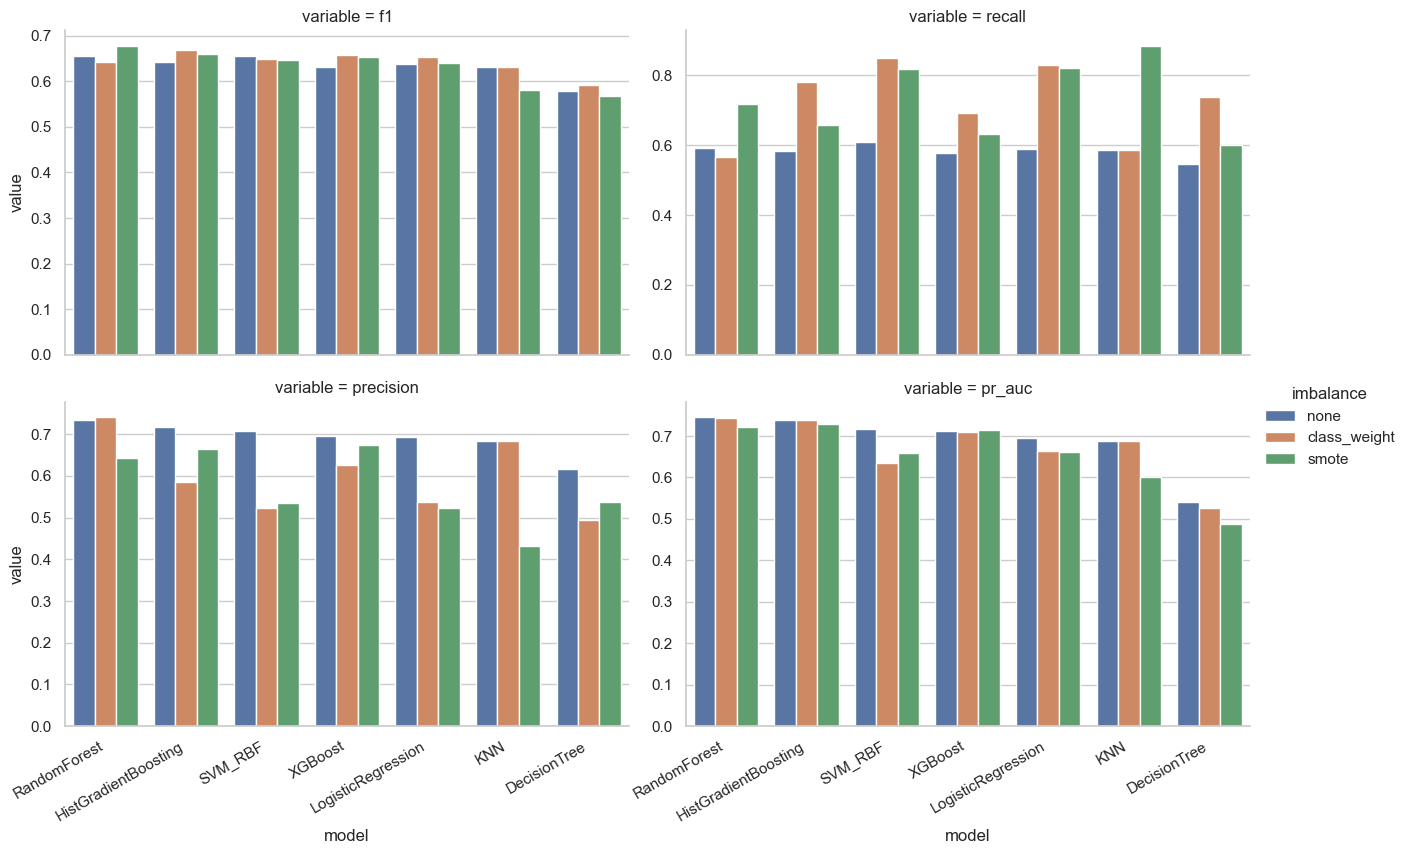

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\baseline_model_comparison.png


In [3]:
melt = baseline.melt(id_vars=["model", "imbalance"], value_vars=["f1", "recall", "precision", "pr_auc"])
g = sns.catplot(data=melt, x="model", y="value", hue="imbalance", col="variable", kind="bar",
                col_wrap=2, height=4, aspect=1.6, sharey=False)
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
save_fig(g.figure, "baseline_model_comparison")

**Write down:** which models win and *why* (tree ensembles capture non-linear interactions and are robust to skew; Logistic Regression / SVM / KNN depend on scaling and suffer from heavy tails; a single Decision Tree overfits). Note how class weights trade precision for recall.

## 2. Hyper-parameter tuning
`RandomizedSearchCV` (40 candidates per model, 5-fold stratified CV), refit on **PR-AUC** because it does not depend on the decision threshold. This can take 10-20 minutes.

In [4]:
best_params, tuning, details = tune_models(X_train_cv, y_train_cv, cv=get_cv())
save_table(tuning, "tuning_summary")
for n, d in details.items():
    save_table(d, f"tuning_cv_results_{n}")
(MODELS_DIR / "best_params.json").write_text(json.dumps(best_params, indent=2))
tuning.drop(columns="best_params").round(4)

Tuning LogisticRegression: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Tuning RandomForest: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Tuning HistGradientBoosting: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Tuning XGBoost: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_summary.csv
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_LogisticRegression.csv
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_RandomForest.csv
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_HistGradientBoosting.csv
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_resul

,model,imbalance_base,cv_pr_auc,cv_roc_auc,cv_f1,cv_recall,cv_precision,cv_pr_auc_std
0,RandomForest,none,0.7526,0.9304,0.6467,0.5799,0.7315,0.0176
1,HistGradientBoosting,none,0.7514,0.9338,0.6514,0.5963,0.7182,0.0182
2,XGBoost,none,0.7512,0.9327,0.6602,0.6048,0.7272,0.0166
3,LogisticRegression,class_weight,0.6668,0.9196,0.6560,0.8191,0.5474,0.0289


In [5]:
# Tuned vs baseline (best baseline per model family, by PR-AUC)
base_best = baseline.sort_values("pr_auc", ascending=False).groupby("model").first()[["imbalance", "f1", "recall", "pr_auc"]]
cmp_ = tuning.set_index("model")[["cv_f1", "cv_recall", "cv_pr_auc"]].join(base_best, how="left", rsuffix="_base")
cmp_["pr_auc_gain"] = cmp_["cv_pr_auc"] - cmp_["pr_auc"]
save_table(cmp_.reset_index(), "tuned_vs_baseline")
cmp_.round(4)

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuned_vs_baseline.csv


,cv_f1,cv_recall,cv_pr_auc,imbalance,f1,recall,pr_auc,pr_auc_gain
model,,,,,,,,
RandomForest,0.6467,0.5799,0.7526,none,0.6542,0.5911,0.7458,0.0068
HistGradientBoosting,0.6514,0.5963,0.7514,none,0.6423,0.5819,0.7393,0.0121
XGBoost,0.6602,0.6048,0.7512,smote,0.6520,0.6310,0.7146,0.0366
LogisticRegression,0.6560,0.8191,0.6668,none,0.6368,0.5891,0.6942,-0.0274


## 3. Final model
The final model is the tuned family with the best CV PR-AUC. You can override it by setting `FINAL_MODEL = "RandomForest"` (etc.) below and justify the choice (performance, stability, interpretability, speed).

In [6]:
FINAL_MODEL = None      # e.g. "HistGradientBoosting"; None = best CV PR-AUC
BETA = 1.0              # >1 favours recall (use 2.0 if missing a buyer costs more than a wasted offer)

name = FINAL_MODEL or tuning.iloc[0]["model"]
imb = tuning.set_index("model").loc[name, "imbalance_base"]
print("Final model:", name, "| imbalance handling:", imb)
print(best_params[name])

Final model: RandomForest | imbalance handling: none
{'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 424}


In [7]:
# Threshold chosen on OUT-OF-FOLD training predictions (the test set stays untouched)
oof = cross_val_predict(make_final_pipeline(name, imb, best_params[name]), X_train, y_train,
                        cv=get_cv(), method="predict_proba", n_jobs=N_JOBS)[:, 1]
thr, f = best_f_threshold(y_train, oof, beta=BETA)
print(f"Decision threshold = {thr:.3f}  (out-of-fold F{BETA:g} = {f:.3f})")

Decision threshold = 0.381  (out-of-fold F1 = 0.687)


In [8]:
# One-time hold-out evaluation
pipe = make_final_pipeline(name, imb, best_params[name]).fit(X_train, y_train)
proba = pipe.predict_proba(X_test)[:, 1]
m_default, m_tuned = holdout_metrics(y_test, proba, 0.5), holdout_metrics(y_test, proba, thr)
final_metrics = pd.DataFrame([{"setting": "threshold=0.5", **m_default}, {"setting": f"threshold={thr:.3f}", **m_tuned}])
save_table(final_metrics, "final_test_metrics")
final_metrics.round(4)

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\final_test_metrics.csv


,setting,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,threshold=0.5,0.5000,0.9105,0.7923,0.7621,0.6204,0.6840,0.938,0.7716
1,threshold=0.381,0.3809,0.8975,0.8251,0.6563,0.7199,0.6866,0.938,0.7716


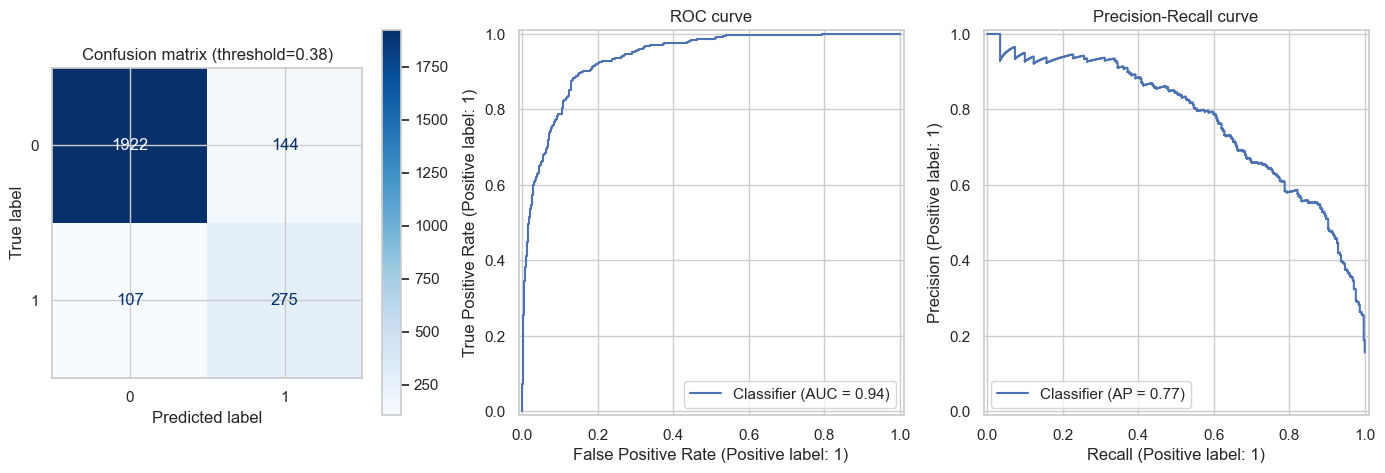

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\final_model_evaluation.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ConfusionMatrixDisplay.from_predictions(y_test, (proba >= thr).astype(int), ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion matrix (threshold={thr:.2f})")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1]); axes[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[2]); axes[2].set_title("Precision-Recall curve")
save_fig(fig, "final_model_evaluation")

### Interpretation - which inputs drive the prediction?

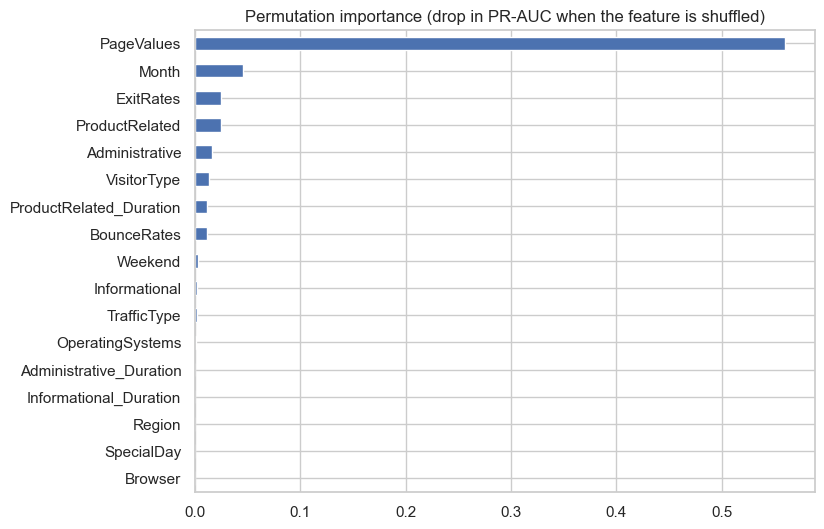

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\final_permutation_importance.png
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\final_permutation_importance.csv


In [10]:
pi = permutation_importance(pipe, X_test, y_test, scoring="average_precision", n_repeats=10,
                            random_state=RANDOM_STATE, n_jobs=N_JOBS)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 6)); imp.plot.barh(ax=ax)
ax.set_title("Permutation importance (drop in PR-AUC when the feature is shuffled)")
save_fig(fig, "final_permutation_importance")
save_table(imp.sort_values(ascending=False).rename("importance").rename_axis("feature").reset_index(), "final_permutation_importance")

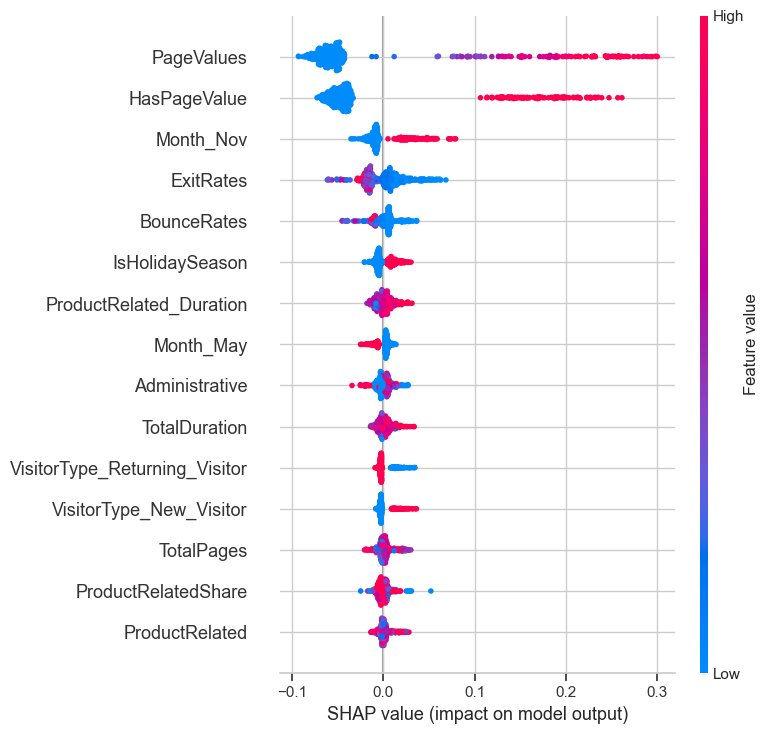

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\final_shap_summary.png


In [11]:
# Optional: SHAP (tree models). Skipped automatically if shap is not installed or the model is not tree-based.
try:
    import shap
    Xt = pipe[:-1].transform(X_test.sample(500, random_state=RANDOM_STATE))
    names = pipe[:-1].get_feature_names_out()
    sv = shap.TreeExplainer(pipe.named_steps["model"]).shap_values(Xt)
    sv = sv[1] if isinstance(sv, list) else (sv[..., 1] if getattr(sv, "ndim", 2) == 3 else sv)
    shap.summary_plot(sv, Xt, feature_names=list(names), show=False, max_display=15)
    save_fig(plt.gcf(), "final_shap_summary")
except Exception as e:
    print("SHAP skipped:", type(e).__name__, e)

## 4. Save the deployment model
The model evaluated above was trained on the training split only. For deployment we refit the same pipeline (same tuned parameters, same threshold) on **all** cleaned data and save it. The saved file contains the complete pipeline, so the backend applies exactly the same preprocessing.

In [12]:
full = load_clean()
deploy = make_final_pipeline(name, imb, best_params[name]).fit(full[FEATURE_COLS], full[TARGET])
art = save_artefact(deploy, thr, name, best_params[name], m_tuned)
save_artefact(pipe, thr, name, best_params[name], m_tuned, path=MODELS_DIR / "final_model_trainonly.joblib")
print("Next: start the backend (uvicorn backend.api:app --port 8000) and the frontend (streamlit run frontend/streamlit_app.py)")

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\models\final_model.joblib
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\models\final_model_trainonly.joblib
Next: start the backend (uvicorn backend.api:app --port 8000) and the frontend (streamlit run frontend/streamlit_app.py)
